# **MÓDULO 21 - Projeto de Credit Score - Árvore de Decisão**


No módulo 17, vocês realizaram a primeira etapa do projeto de crédito de vocês. Então fizeram o tratamendo dos dados, balancearam as classes, transformaram as variáveis categóricas e separam base de treino e teste. Já no módulo 14, aplicaram a base já tratada o algoritmo de Naive Bayes, onde avaliaram os resultados das previsões. Nesse módulo aplicaremos a nossa base o algoritmo da árvore de decisão.

In [21]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
import plotly.figure_factory as ff
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1) Comece carregando as bases de treino (X e y) e teste (X e y).
Verifique se o número de linhas condiz, se as variáveis estão corretas sendo apenas a de score para y e as demais nas bases de X e por último, se Y está balanceada no teste.

In [3]:
x_train = pd.read_csv('Dados/01. x_train_balanced.csv')
y_train = pd.read_csv('Dados/02. y_train_balanced.csv')
x_test = pd.read_csv('Dados/03. x_test.csv')
y_test = pd.read_csv('Dados/04. y_test.csv')

In [4]:
x_train

,Age,Income,Number of Children,Gender_Encoded,Marital_Status_Encoded,Home_Ownership_Encoded,Education_Encoded
0,26,45000.000000,0,0,1,1,1.000000
1,29,27500.000000,0,0,1,1,0.000000
2,25,62500.000000,0,0,1,1,2.000000
3,29,68000.000000,2,0,0,0,4.000000
4,31,65000.000000,0,1,1,1,2.000000
...,...,...,...,...,...,...,...
247,29,43703.466973,0,0,1,1,1.000000
248,34,47500.000000,0,1,1,1,1.000000
249,29,57500.000000,0,0,1,1,1.572459
250,25,60063.547817,0,0,1,1,2.000000


In [5]:
y_train

,Credit_Score_Encoded
0,1.0
1,0.0
2,1.0
3,1.0
4,1.0
...,...
247,1.0
248,1.0
249,1.0
250,1.0


In [6]:
x_test

,Age,Income,Number of Children,Gender_Encoded,Marital_Status_Encoded,Home_Ownership_Encoded,Education_Encoded
0,25,55000.0,0,0,1,1,2.0
1,48,87500.0,1,0,0,0,4.0
2,26,55000.0,1,0,0,0,2.0
3,39,62500.0,2,0,0,0,2.0
4,35,90000.0,1,0,0,0,4.0
5,25,55000.0,0,0,1,1,2.0
6,48,82500.0,1,0,0,0,4.0
7,48,82500.0,1,0,0,0,4.0
8,36,95000.0,2,0,0,0,3.0
9,36,95000.0,1,0,0,0,0.0


In [7]:
y_test

,Credit_Score_Encoded
0,1.0
1,2.0
2,1.0
3,2.0
4,2.0
5,1.0
6,2.0
7,2.0
8,2.0
9,2.0


# 2) Explique com suas palavras, qual o passo a passo para a aplicação do algoritmo da árvore de decisão, não esqueça de citar a etapa de avaliação do modelo e também como podemos melhorar nosso modelo.

A aplicação do algoritmo da árvore de decisão consiste nos seguintes passos:

### Pré Processamento dos Dados

   - Parte 01:
        - Verificar as variáveis do conjunto de dados. Remover as que não forem pertinentes da análise.
        - Analisar e corrigir a tipagem dos dados.
        - Verificar valores nulos, substituir ou remover da base.
        - Verificar possíveis erros de digitação em variáveis categóricas.
   - Parte 02:
        - Realizar a análise univariada, que consiste em analisar a distribuição e o balanceamento de cada variável presente no conjunto de dados. Retirar os primeiros insights.
        - Identificar e tratar possíveis outliers, remover ou substituir por medidas de centralidade (média ou mediana).
        - Realizar a análise bivariada, que consiste em retirar insights do relacionamento das variáveis entre si.
   - Parte 03:
        - Aplicar técnicas de transformação de variáveis categóricas para numerais (Label Encoder ou One-Hot Encoder).
        - Analisar a correlação das variáveis entre si.
        - Realizar a separação da base em Treino e Teste.
        - Validar o balanceamento da variável a ser prevista nas bases de treino. Caso necessário, aplicar técnicas de balanceamento como Undersampling ou Oversampling.

### Aplicação da Árvore de Decisão

   - Construir o algoritmo do modelo e aplicar a base de treino.
   - Realizar as primeiras previsões na base de treino e avaliar o desempenho do modelo com métricas como: Acurácia, Recall, Precision e F1-Score.
   - Aplicar a base teste, realizar as previsões, avaliar o desempenho e comparar com a métricas das bases de treino.
   - Simplificar e aprimorar o modelo. Selecionar as principais variáveis usando o feature_importances_ e aplicar a nova base no modelo.
   - Avaliar novamente o desempenho do modelo e realizar possíveis ajustes até apresentar um desempenho satisfatório na previsão da categória desejada.

# 3) Aplique o algortimo da árvore de decisão aos dados de treinamento, utilizando critério de Gini e random state = 0.
Traga a acurácia para o modelo com os dados de treino.

In [8]:
arvore_credit_score = DecisionTreeClassifier(criterion = 'gini', random_state = 0)
arvore_credit_score.fit(x_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

In [16]:
previsoes_treino = arvore_credit_score.predict(x_train)
acuracia_treino = accuracy_score(y_train, previsoes_treino)
print("Acurácia:", acuracia_treino)

Acurácia: 1.0


### **Insight**

A principio o modelo acertou 100% das previsões feitas na base de Treino

# 4) Aplique o modelo aos dados de teste e realize a avaliação dos resultados. Não se esqueça de avaliar com as suas palavras e comparar o desempenho da base treino com a teste.

In [18]:
previsoes_teste = arvore_credit_score.predict(x_test)
relatorio = classification_report(y_test, previsoes_teste)
print("Relatório de Classificação")
print(relatorio)

Relatório de Classificação
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00         6
         1.0       0.75      1.00      0.86         6
         2.0       1.00      0.93      0.96        29

    accuracy                           0.95        41
   macro avg       0.92      0.98      0.94        41
weighted avg       0.96      0.95      0.95        41



In [22]:
# MATRIZ DE CONFUSÃO
conf_matrix = confusion_matrix(y_test, previsoes_teste)

class_names = ['Low', 'Average', 'High']

# Matriz de Confusão
fig = ff.create_annotated_heatmap(
    z = conf_matrix,
    x = class_names,
    y = class_names,
    colorscale = 'Blues',
    showscale = True
)

# Estilizando
fig.update_layout(
    title = 'Matriz de Confusão',
    xaxis_title = 'Rótulos Previstos',
    yaxis_title = 'Rótulos Verdadeiros',
    font = dict(
        family = 'Arial',
        size = 12,
        color = 'black'
    ),
    template = 'plotly'
)

fig.show()

### **Insight**

- O modelo conseguiu acertar todas as previsões de clientes com Baixo score de crédito, apresentando um desempenho muito satisfatório nessa categoria.
- O modelo superestimou a classe "Médio", acertando 75% das previsões realizadas para essa categoria (Precision). Por outro lado, identificou corretamente 100% dos clientes que realmente pertenciam a essa classe (Recall).
- O modelo acertou 100% de todas as previsões feitas como Alto score de crédito (Precision), entretanto, acertou 93% de todos clientes que de fato possuiam Alto score de crédito.

Em resumo, o modelo apresentou um desempenho muito satisfatório, com uma taxa de acerto de 95% de todas as previsões. O modelo generalizou muito bem os dados de clientes com Baixo score de crédito, porém, apresentou uma leve dificuldade em distinguir clientes de Alto score com os de score Médio, classificando incorretamente dois clientes da categoria "High" como "Average".

# 5) Plote a árvore de decisão.
É possível fazer uma avaliação visual? Qual a profundidade da árvore?

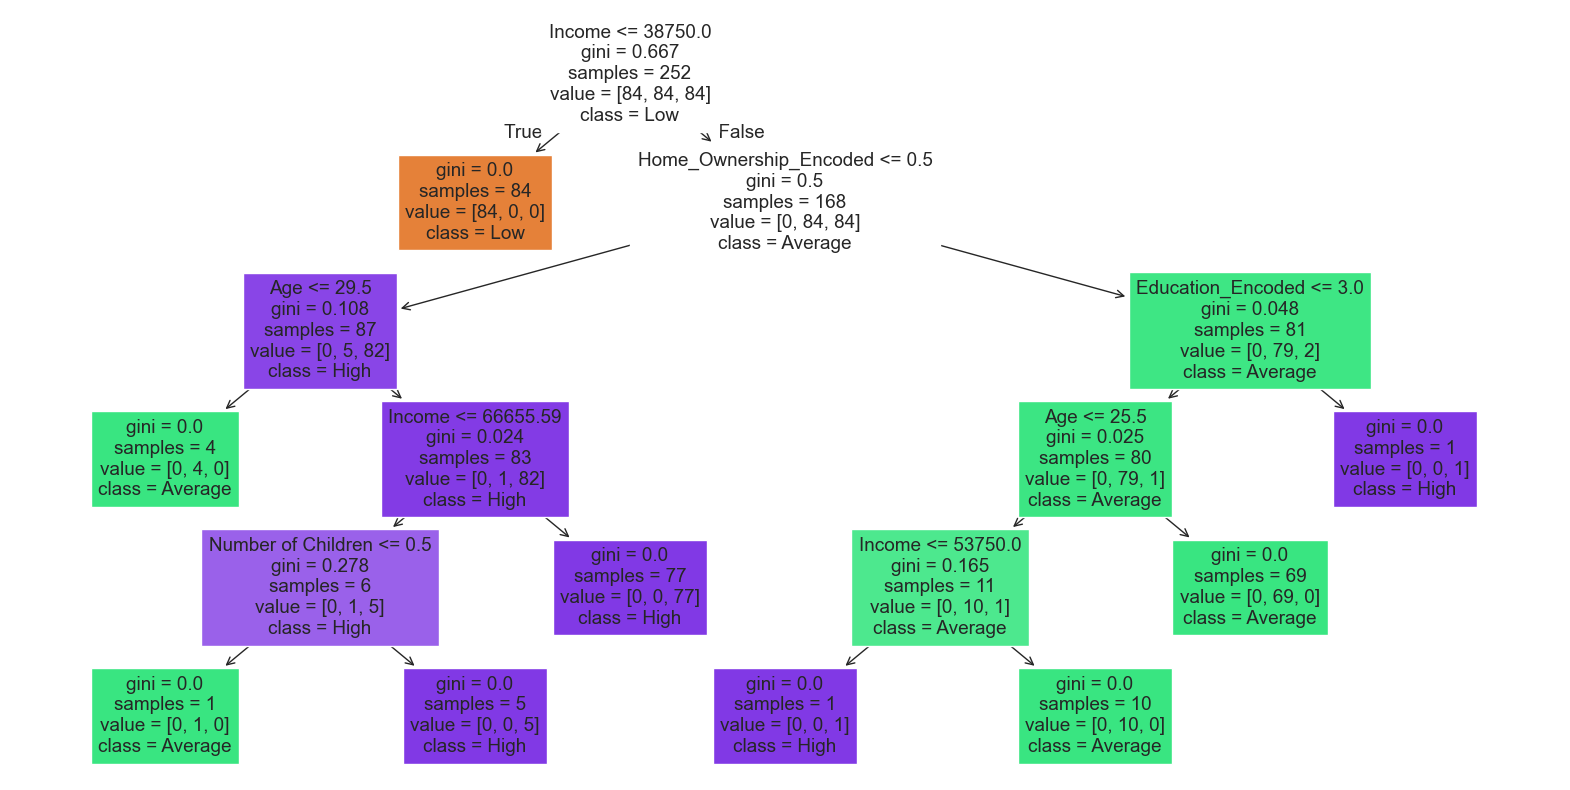

In [23]:
plt.figure(figsize = (20, 10))
plot_tree(
    arvore_credit_score,
    filled = True,
    feature_names = x_train.columns,
    class_names = ['Low', 'Average', 'High']
)
plt.show()

Sim é possivel claramente entender as decisões que estão sendo tomadas pela Árvore. O "teste lógico" sempre vem acima da medida Gini (Nós), o Ramo positivo é sempre à esquerda, o negativo sempre à direita. Value representando as categorias que chegaram seguindo cada teste lógico aplicado até o momento e Class representando a categória definida no final do bloco.

Entendo que a profundidade é 5.

# 6) Identifique as 2 principais features do modelo.


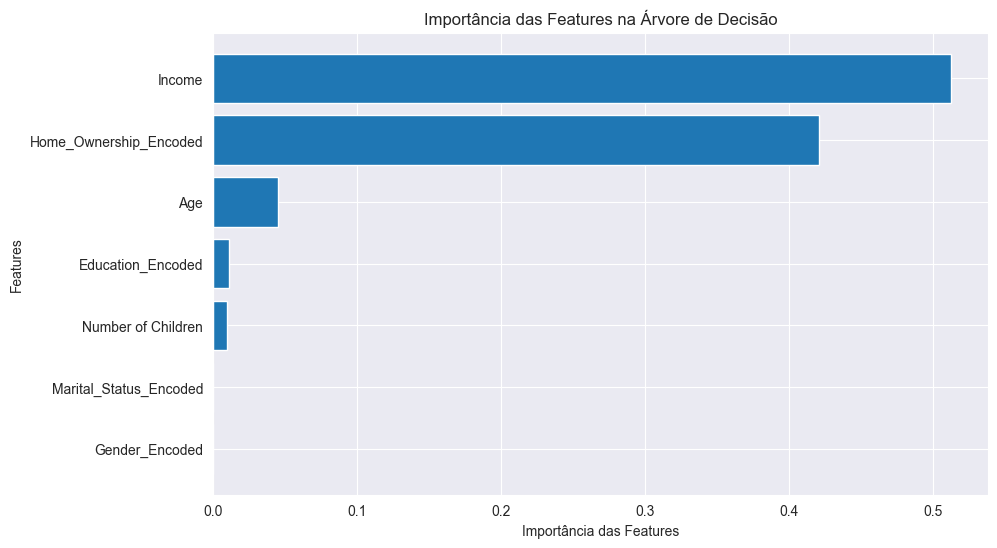

In [34]:
# Obtendo a importância das características do modelo
importancias_features = arvore_credit_score.feature_importances_

# Índices ordenados do maior para o menor
indices = np.argsort(importancias_features)[::-1]

# Reordenando nomes e importâncias
nomes_features = x_train.columns[indices]
importancias_ordenadas = importancias_features[indices]

# Criando um gráfico de barras para visualizar a importância das características
plt.figure(figsize = (10, 6))
plt.barh(
    nomes_features,
    importancias_ordenadas
)

# Invertendo o eixo Y para a feature mais importante ficar no topo
plt.gca().invert_yaxis()

plt.xlabel('Importância das Features')
plt.ylabel('Features')
plt.title('Importância das Features na Árvore de Decisão')
plt.show()

# 7) Rode um modelo de árvore de decisão apenas com as 2 principais features encontradas. E avalie os resultados. Para você o desempenho da árvore está melhor que o modelo anterior? Justifique.

In [36]:
# Reduzindo as bases de dados
x_train_reduzido = x_train[['Income', 'Home_Ownership_Encoded']]
x_test_reduzido = x_test[['Income', 'Home_Ownership_Encoded']]

In [37]:
# Criando o modelo reduzido
arvore_credit_score_reduzido = DecisionTreeClassifier(criterion = 'gini', random_state = 0)
arvore_credit_score_reduzido.fit(x_train_reduzido, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

In [42]:
previsoes_modelo_reduzido = arvore_credit_score_reduzido.predict(x_test_reduzido)
relatorio_novo_modelo = classification_report(y_test, previsoes_modelo_reduzido)
print("Relatório de Classificação Modelo Reduzido")
print(relatorio_novo_modelo)

print("Relatório de Classificação Modelo Completo")
print(relatorio)

Relatório de Classificação Modelo Reduzido
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00         6
         1.0       0.83      0.83      0.83         6
         2.0       0.97      0.97      0.97        29

    accuracy                           0.95        41
   macro avg       0.93      0.93      0.93        41
weighted avg       0.95      0.95      0.95        41

Relatório de Classificação Modelo Completo
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00         6
         1.0       0.75      1.00      0.86         6
         2.0       1.00      0.93      0.96        29

    accuracy                           0.95        41
   macro avg       0.92      0.98      0.94        41
weighted avg       0.96      0.95      0.95        41



In [39]:
# MATRIZ DE CONFUSÃO
conf_matrix = confusion_matrix(y_test, previsoes_modelo_reduzido)

class_names = ['Low', 'Average', 'High']

# Matriz de Confusão
fig = ff.create_annotated_heatmap(
    z = conf_matrix,
    x = class_names,
    y = class_names,
    colorscale = 'Blues',
    showscale = True
)

# Estilizando
fig.update_layout(
    title = 'Matriz de Confusão',
    xaxis_title = 'Rótulos Previstos',
    yaxis_title = 'Rótulos Verdadeiros',
    font = dict(
        family = 'Arial',
        size = 12,
        color = 'black'
    ),
    template = 'plotly'
)

fig.show()

### **Insight**

- O modelo continuou apresentando um desempenho excelente para classe "Low", acertando 100% das previsões realizadas.
- O modelo apresentou maior dificuldade de distinguir a classe "Average" da "High". Realizando um maior número de previsões incorretas, classificando corretamente 5 de 6 clientes "Average"
- Para a classe "High", o modelo desempenhou relativamente melhor, classificando corretamente um cliente a mais que o anterior.

Em geral, analisando o número bruto de previsões assertivas, ambos os modelos desempenharam igual, com uma taxa de acerto 95%. Por sua vez, o F1-Score médio caiu de 0.94 para 0.93, muito impulsionado pelo modelo não conseguir prever corretamente todos os clientes "Average". Em vista disso, entendo que o modelo apresentou um desempenho relativamente pior ao anterior.

# 8) Compare os resultados obtidos com a árvore de decisão com os resultados do Naive Bayes (Exercício módulo 20). Qual parece ter se adequado melhor aos dados e tem melhores resultados de avaliação? Justifique.

### Desempenho Modelo de Naive Bayes

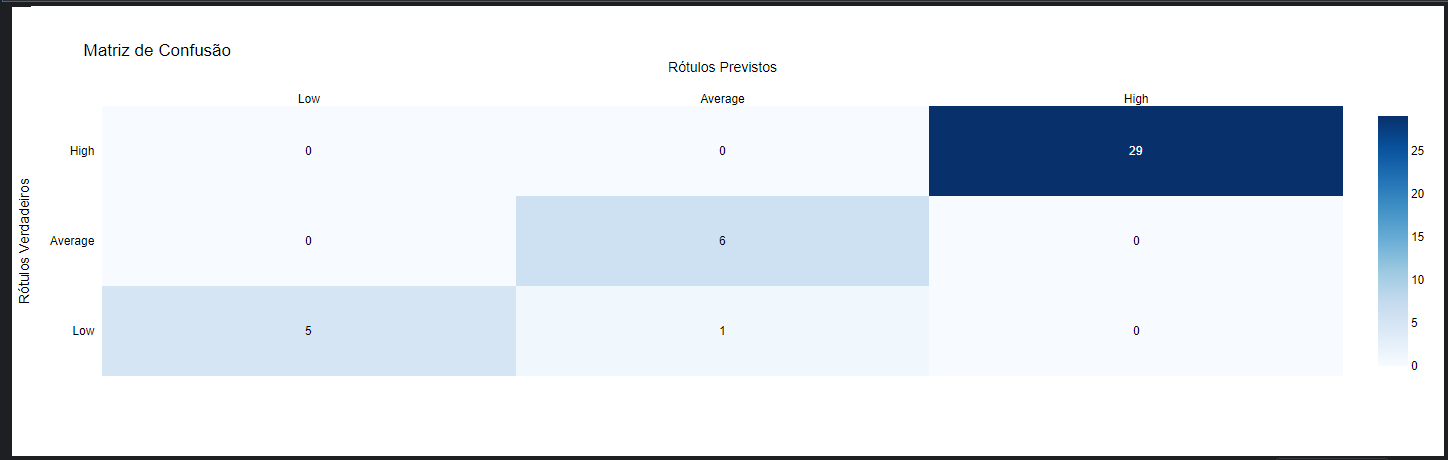

---

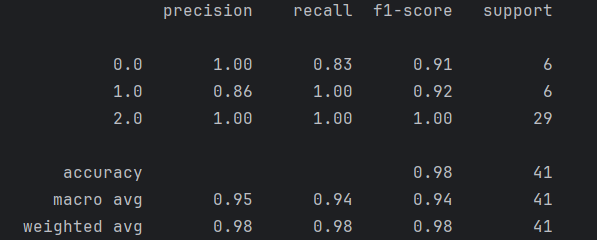
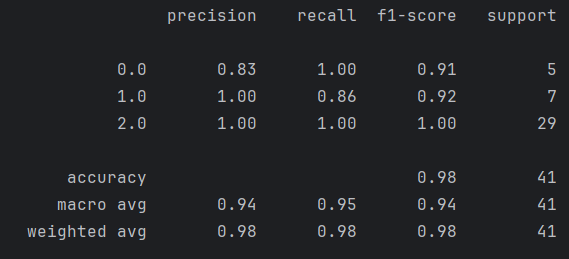
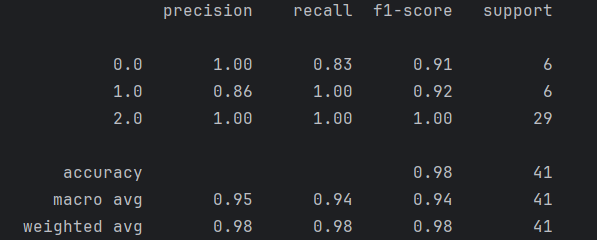

Comparando o desempenho bruto de ambos os modelos:
- Naive Bayes teve uma taxa de acerto de 98% de todas as previsões, enquanto a Árvore de Decisão teve 95%.
- O F1-Score médio de ambos os modelos foram 0.94
- A Árvore de Decisão apresentou dificuldades em distinguir clientes "High" de "Average", classificando incorretamente dois clientes "High" como "Average". Por outro lado, o modelo de Naive Bayes classificou apenas um cliente "Low" como "Average"


Sem levar em conta uma possível regra de negócio, em geral, entendo que o modelo de Naive Bayes possuiu um desempenho mais satisfatório, considerando que o modelo apresentou apenas uma classificação incorreta e que sua taxa de acerto é superior a Árvore de Decisão.

Agora considerando que há uma regra de negócio que diz que o ideal é o modelo errar para baixo, entendo que a Árvore de Decisão será a melhor a ser utilizada nesse cenário. De qualquer maneira esse modelo também apresentou um desempenho excelente, com uma taxa de acerto de 95%.